In [1]:
#Import Libs
from matplotlib import pyplot as plot
import matplotlib as mpl
import urllib.request
import urllib.parse
import numpy as np
import math
import cv2

In [2]:
image_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Datasets/Bolts%20and%20Nuts/img01.jpg'

In [3]:
#Open the Image
with urllib.request.urlopen(image_url) as url:
    s = url.read()

In [4]:
#Convert to a Numpy Array and Decode with cv2
img = cv2.imdecode(np.frombuffer(s, np.uint8), -1)

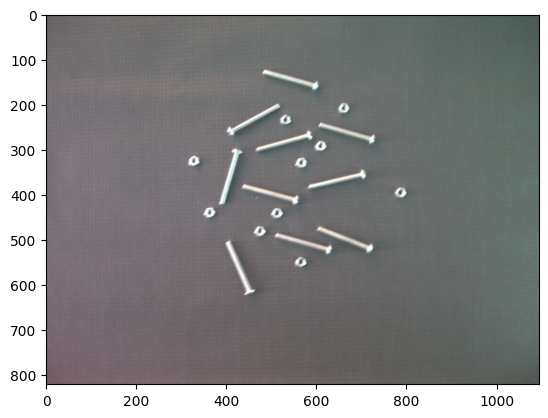

In [5]:
#Show the Image
plot.imshow(img,cmap='gray')
plot.show()

In [6]:
#Function to Pre-processing Image
def process_image(input_img):
    B, G, R = cv2.split(input_img)
    img_gray = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
    otsu_threshold, img_bin = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return B, G, R, img_gray, img_bin, otsu_threshold

In [7]:
#Apply the Function and Show the OTSU Value
B, G, R, img_gray, img_bin, otsu_threshold = process_image(img)
print("Threshold Value (OTSU): ", otsu_threshold)

Threshold Value (OTSU):  163.0


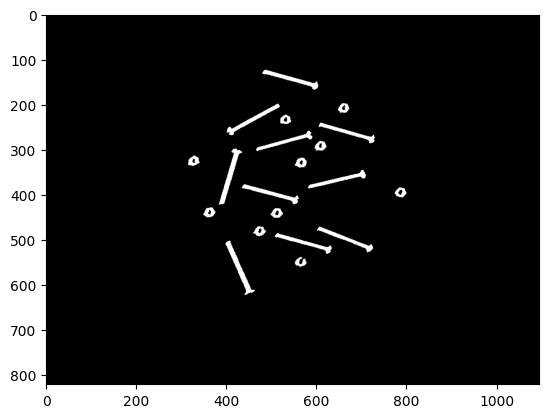

In [8]:
# Show the Initial Results
plot.imshow(img_bin, cmap='gray')
plot.show()

### **Fine-tuning**

After the **Threshold Phase**, to ensure that the computer vision system effectively achieves its objectives, it may be necessary to **fine-tune** the `Threshold` value (`THRESH_BINARY`) when the initial results are not satisfactory. The logic implemented is as follows:

- If the number of connected components detected is **greater than 20 and less than 100**, the `THRESH_BINARY` value is automatically **updated to 140**.
- If the number of connected components detected is **greater than 100**, the `THRESH_BINARY` value is automatically **updated to 220**.

This adjustment aims to refine the segmentation, especially in scenarios where a standard binarization results in excessive noise or object fragmentation, forcing a cleaner separation with a more restrictive threshold.

In [9]:
#Check COnnected Componentes (Using 8 for Connectivity)
(numCCs, imgLabels, stats, centroids) = cv2.connectedComponentsWithStats(img_bin, connectivity=8)

In [10]:
#File-Tuning
if numCCs > 20 and numCCs < 100:
    T = 140
    T ,img_bin = cv2.threshold(img_gray, T, 255, cv2.THRESH_BINARY)
elif numCCs > 100:
    T = 220
    T ,img_bin = cv2.threshold(img_gray, T, 255, cv2.THRESH_BINARY)

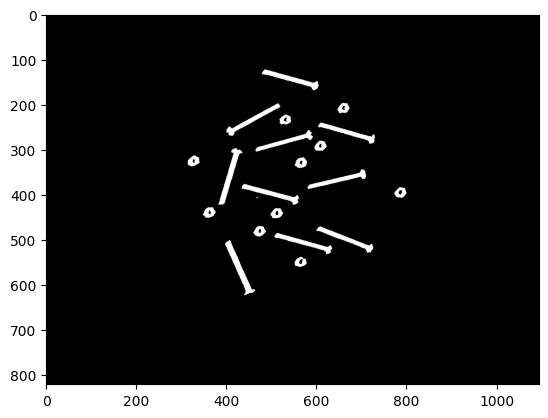

In [11]:
# Show the Results
plot.imshow(img_bin, cmap='gray')
plot.show()

In [12]:
#Check COnnected Componentes (Using 8 for Connectivity)
(numCCs, imgLabels, stats, centroids) = cv2.connectedComponentsWithStats(img_bin, connectivity=8)

In [13]:
#Total of Components
print("Total of Components Connected: " + str(numCCs-1))

Total of Components Connected: 21


In [14]:
#Show the Area of Each Component Detected
for i in range (numCCs):
    print("Object " + str(i) + " = " + str(stats[i,cv2.CC_STAT_AREA]))

Object 0 = 879752
Object 1 = 1419
Object 2 = 410
Object 3 = 1377
Object 4 = 387
Object 5 = 1333
Object 6 = 1267
Object 7 = 415
Object 8 = 1654
Object 9 = 436
Object 10 = 437
Object 11 = 1329
Object 12 = 1412
Object 13 = 404
Object 14 = 7
Object 15 = 443
Object 16 = 416
Object 17 = 419
Object 18 = 1391
Object 19 = 1350
Object 20 = 1738
Object 21 = 378


In [15]:
#Start the Variables
bolts = 0
nuts = 0

### **Object Classification (Bolts and Nuts)**

A loop is executed from `0` to the number of detected connected components (`numCCs`). Within this loop, each component is classified based on its area using the following logic:

- If the area is greater than **850** and less than **3500**, the object is classified as a **Bolt**.
- If the area is greater than **220** and less than **850**, the object is classified as a **Nut**.

After classification, a count of these items is performed, and messages can be displayed to indicate the area of each component.

In [16]:
#Object Classification
for i in range (numCCs):
    if stats[i,cv2.CC_STAT_AREA] > 850 and stats[i,cv2.CC_STAT_AREA] < 3500:
        bolts = bolts + 1
    if stats[i,cv2.CC_STAT_AREA] > 220 and stats[i,cv2.CC_STAT_AREA] < 850:
        nuts = nuts + 1

In [17]:
#Show the Results (Classification)
print("Bolts: " + str(bolts))
print("Nuts: " + str(nuts))

Bolts: 10
Nuts: 10


### **Final Validation (Bolts and/or Nuts)**

This section performs a final validation based on the counted number of bolts and nuts:

- If there are **10 Bolts and 10 Nuts**: The set is **Approved**!
- If there are **< 10 Bolts and 10 Nuts**: The set is **Disapproved**, `n` Bolts are missing.
- If there are **10 Bolts and < 10 Nuts**: The set is **Disapproved**, `n` Nuts are missing.
- If there are **< 10 Bolts and < 10 Nuts**: The set is **Disapproved**, `n` Bolts and `n` Nuts are missing.

In [18]:
#Final Validation
if bolts == 10 and nuts == 10:
    result = "Set Approved!"
elif bolts < 10 and nuts == 10:
    result = "Set Disapproved!," + str((10 - bolts)) + " Bolt(s) Missing"
elif bolts == 10 and nuts < 10:
    result = "Set Disapproved!," + str((10 - nuts)) + " Nut(s) Missing"
elif bolts < 10 and nuts < 10:
    result = "Set Disapproved!," + str((10 - bolts)) + " Bolt(s) Missing and " + str((10 - nuts)) + " Nut(s) Missing"

Set Approved!
Threshold Value (OTSU):  163.0


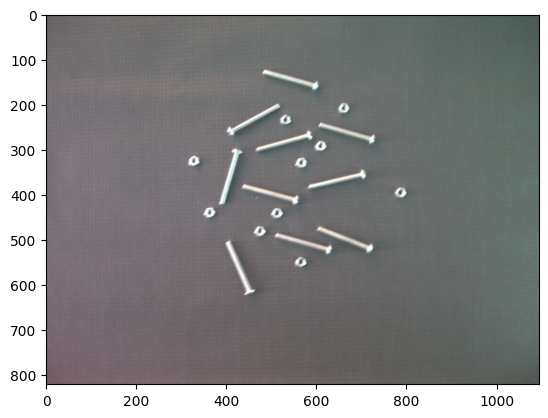

In [19]:
#Final Results
print(result)
print("Threshold Value (OTSU): ", otsu_threshold)
plot.imshow(img,cmap='gray')
plot.show()